# Data Exploration

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
import os


sys.path.append(os.path.abspath("../scripts"))

from evaluate import evaluate_model

# Import modules
import config
import feature_engineering
import data_pipeline
import model_training
import plots
from evaluate import evaluate_model

# Function to reload all custom modules (use when needed)
def reload_modules():
    """Reload all custom modules for development"""
    importlib.reload(config)
    importlib.reload(feature_engineering)
    importlib.reload(data_pipeline)
    importlib.reload(model_training)
    importlib.reload(plots)
    print("All modules reloaded!")

In [3]:
df = data_pipeline.load_data("04-03-24", "A1.csv")
df.columns.values

array(['mode', 'ox/red', 'error', 'control changes', 'Ns changes',
       'counter inc.', 'Ns', 'I Range', 'time/s', 'control/V/mA',
       'Ecell/V', 'I/mA', 'dq/mA.h', '(Q-Qo)/mA.h', '|Energy|/W.h',
       'freq/Hz', '|Z|/Ohm', 'Phase(Z)/deg', 'Q charge/discharge/mA.h',
       'half cycle', 'Energy charge/W.h', 'Energy discharge/W.h',
       'Capacitance charge/µF', 'Capacitance discharge/µF', 'step time/s',
       'z cycle', 'Re(Z)/Ohm', 'Im(Z)/Ohm', 'Re(Y)/Ohm-1', 'Im(Y)/Ohm-1',
       '|Y|/Ohm-1', 'Phase(Y)/deg', 'x', 'Q discharge/mA.h',
       'Q charge/mA.h', 'Capacity/mA.h', 'Efficiency/%', 'control/V',
       'control/mA', 'cycle number', 'P/W', 'R/Ohm'], dtype=object)

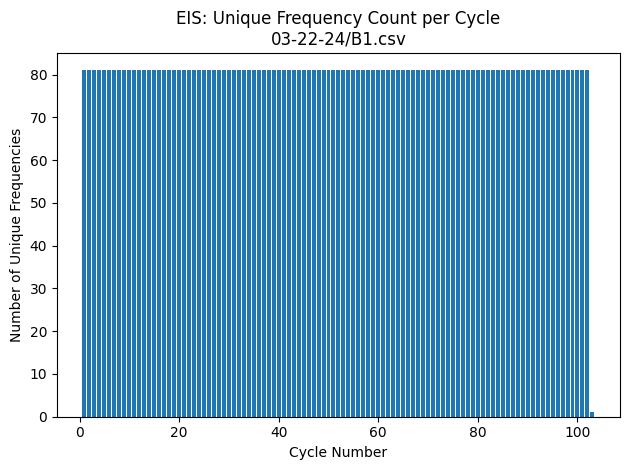

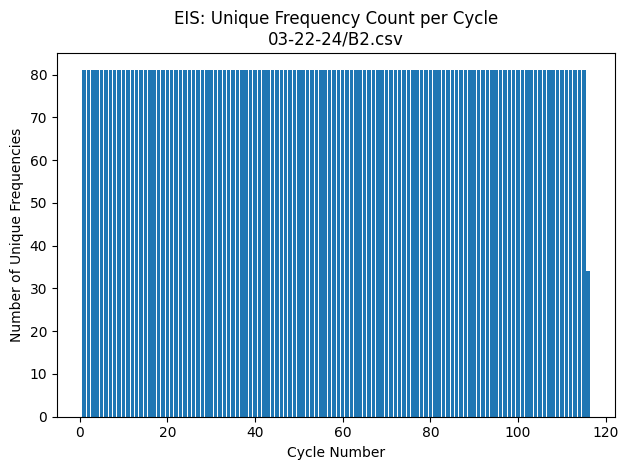

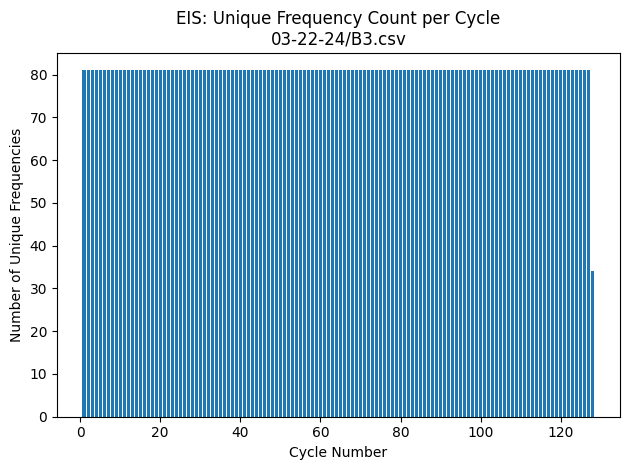

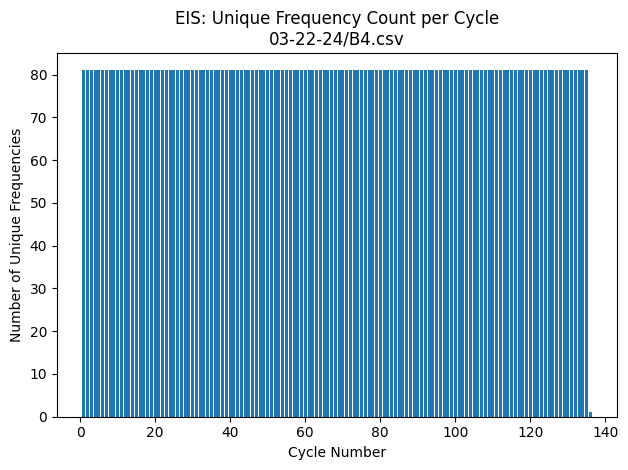

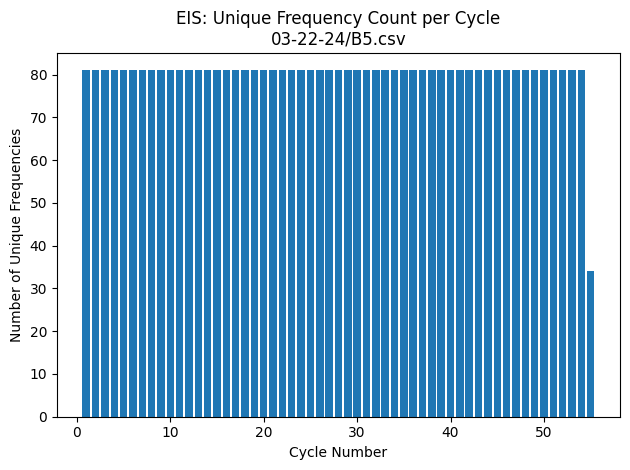

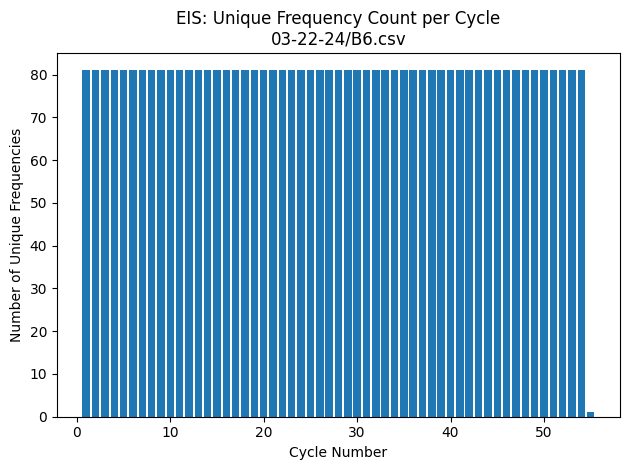

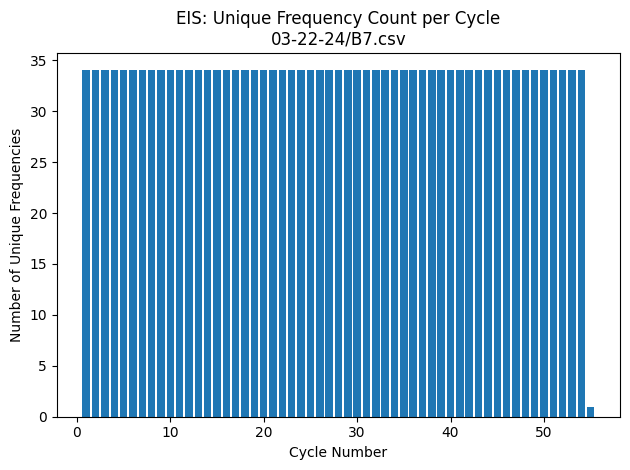

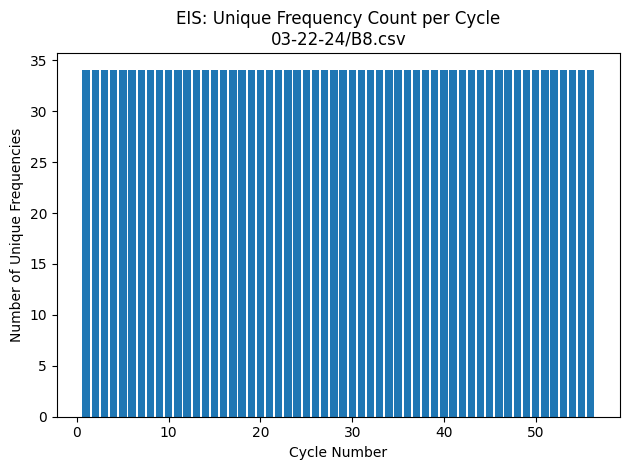

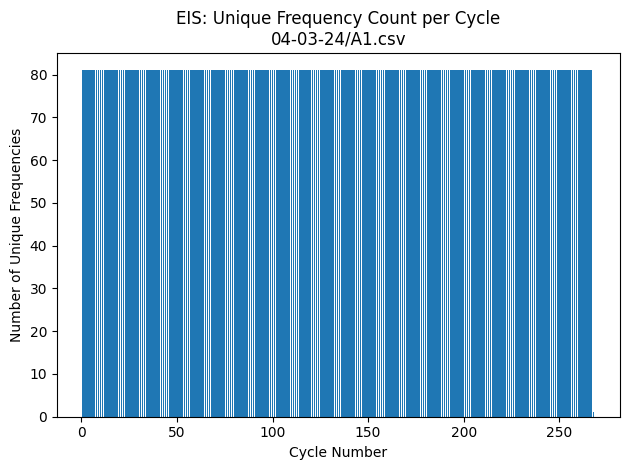

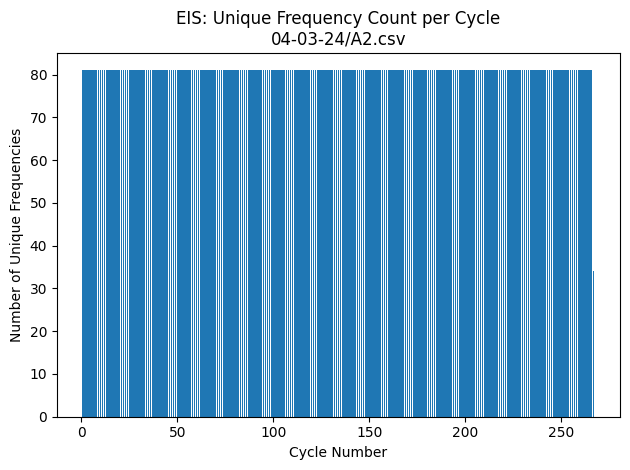

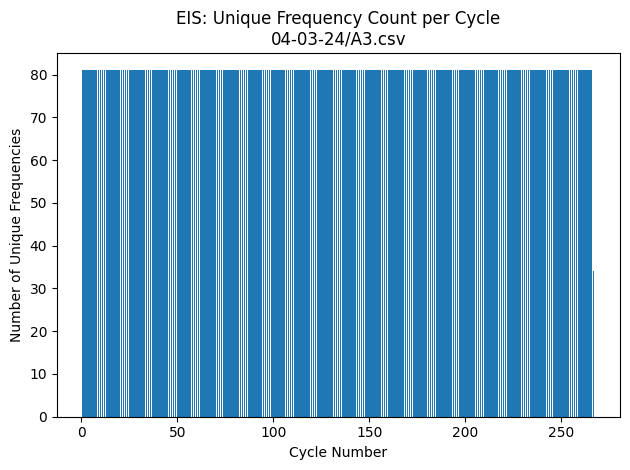

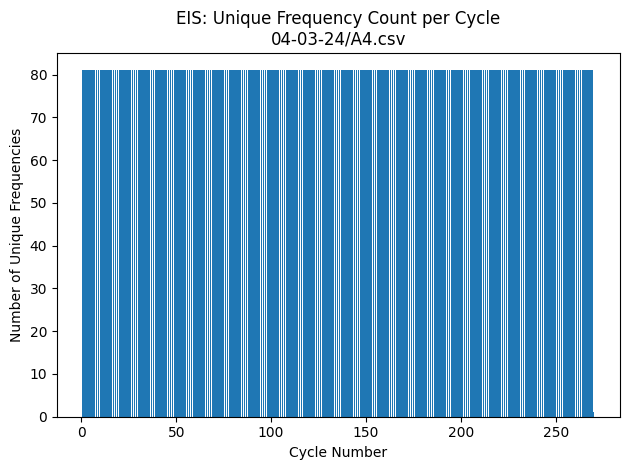

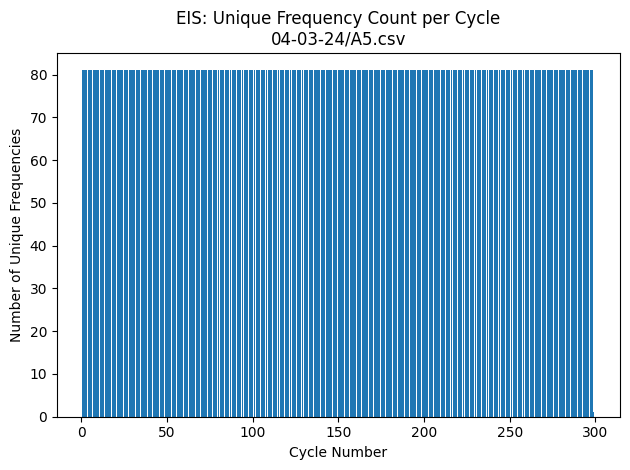

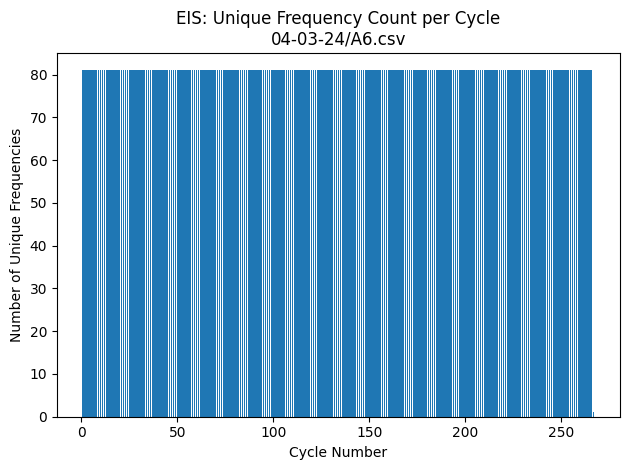

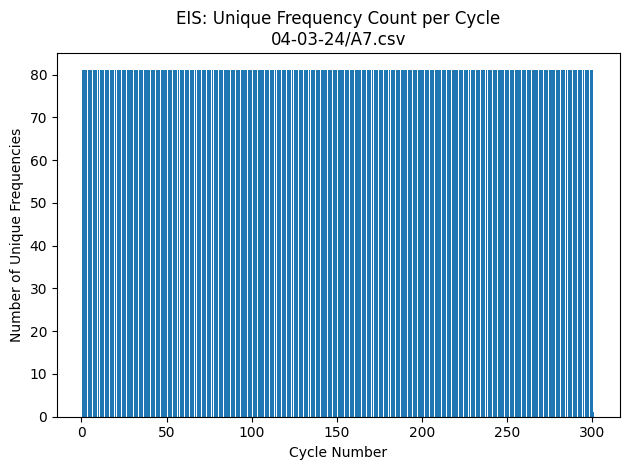

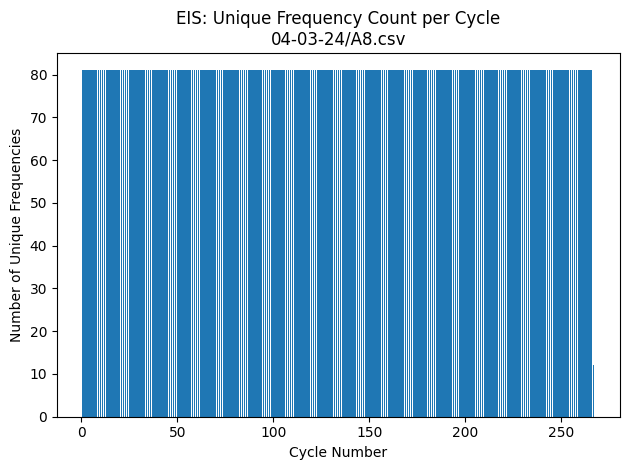

In [4]:
# Adjust this to point at the parent folder that contains your date-folders
data_root = "../data"

for folder in sorted(os.listdir(data_root)):
    folder_path = os.path.join(data_root, folder)
    if not os.path.isdir(folder_path):
        continue

    for filename in sorted(os.listdir(folder_path)):
        if not filename.lower().endswith('.csv'):
            continue

        # 1) Load
        df = data_pipeline.load_data(folder, filename)

        # 2) Compute unique-frequency count per cycle
        freq_counts = (
            df
            .groupby('cycle number')['freq/Hz']
            .nunique()
            .reset_index(name='unique_freq_count')
        )

        # 3) Plot
        plt.figure()
        plt.bar(freq_counts['cycle number'], freq_counts['unique_freq_count'])
        plt.xlabel('Cycle Number')
        plt.ylabel('Number of Unique Frequencies')
        plt.title(f'EIS: Unique Frequency Count per Cycle\n{folder}/{filename}')
        plt.tight_layout()
        plt.show()


## Preprocess for exploration

In [5]:
df = data_pipeline.load_data("04-03-24", "A4.csv")

df = df[(df['freq/Hz'] > 0.2) & (df['freq/Hz'] <= 20000)]
unique_freqs = np.array(df['freq/Hz'].unique())
unique_freqs.sort()

print(unique_freqs)

[2.54e-01 3.40e-01 4.56e-01 6.12e-01 8.22e-01 9.99e-01 1.10e+00 1.33e+00
 1.48e+00 1.78e+00 1.99e+00 2.37e+00 2.66e+00 3.16e+00 3.57e+00 4.22e+00
 4.80e+00 5.62e+00 6.43e+00 7.50e+00 8.64e+00 1.00e+01 1.16e+01 1.33e+01
 1.55e+01 1.78e+01 2.09e+01 2.37e+01 2.80e+01 3.16e+01 3.75e+01 4.22e+01
 5.03e+01 5.62e+01 6.76e+01 7.50e+01 9.06e+01 1.02e+02 1.22e+02 1.35e+02
 1.63e+02 1.78e+02 2.19e+02 2.37e+02 2.94e+02 3.16e+02 3.94e+02 4.22e+02
 5.29e+02 5.64e+02 7.10e+02 7.50e+02 9.52e+02 1.00e+03 1.28e+03 1.33e+03
 1.71e+03 1.78e+03 2.30e+03 2.37e+03 3.09e+03 3.16e+03 4.14e+03 4.22e+03
 5.56e+03 5.62e+03 7.45e+03 7.50e+03 1.00e+04]


In [6]:
unique_counts_by_cycle = {}

# Get a sorted list of unique cycle numbers.
all_cycles = sorted(df['cycle number'].unique())

# Loop through each cycle, count, and print the unique frequencies.
for cycle in all_cycles:
    # Filter the DataFrame for the current cycle and count unique frequencies
    unique_count = len(np.unique(df[df['cycle number'] == cycle]['freq/Hz']))
    unique_counts_by_cycle[cycle] = unique_count
    print(f"Cycle {cycle} has {unique_count} unique frequency points.")


Cycle 1.0 has 69 unique frequency points.
Cycle 2.0 has 69 unique frequency points.
Cycle 3.0 has 69 unique frequency points.
Cycle 4.0 has 69 unique frequency points.
Cycle 5.0 has 69 unique frequency points.
Cycle 6.0 has 69 unique frequency points.
Cycle 7.0 has 69 unique frequency points.
Cycle 8.0 has 69 unique frequency points.
Cycle 9.0 has 69 unique frequency points.
Cycle 10.0 has 69 unique frequency points.
Cycle 11.0 has 69 unique frequency points.
Cycle 12.0 has 69 unique frequency points.
Cycle 13.0 has 69 unique frequency points.
Cycle 14.0 has 69 unique frequency points.
Cycle 15.0 has 69 unique frequency points.
Cycle 16.0 has 69 unique frequency points.
Cycle 17.0 has 69 unique frequency points.
Cycle 18.0 has 69 unique frequency points.
Cycle 19.0 has 69 unique frequency points.
Cycle 20.0 has 69 unique frequency points.
Cycle 21.0 has 69 unique frequency points.
Cycle 22.0 has 69 unique frequency points.
Cycle 23.0 has 69 unique frequency points.
Cycle 24.0 has 69 un

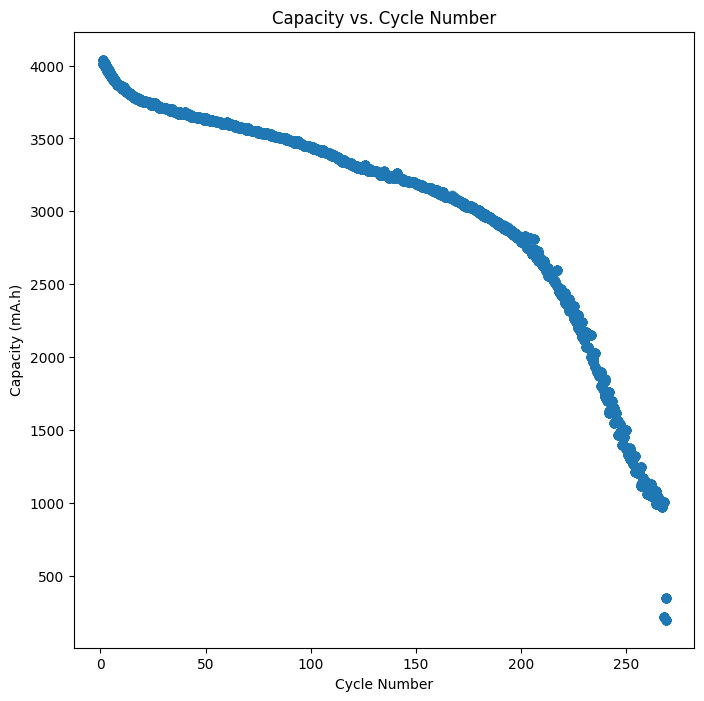

In [7]:
plots.degradation(df)

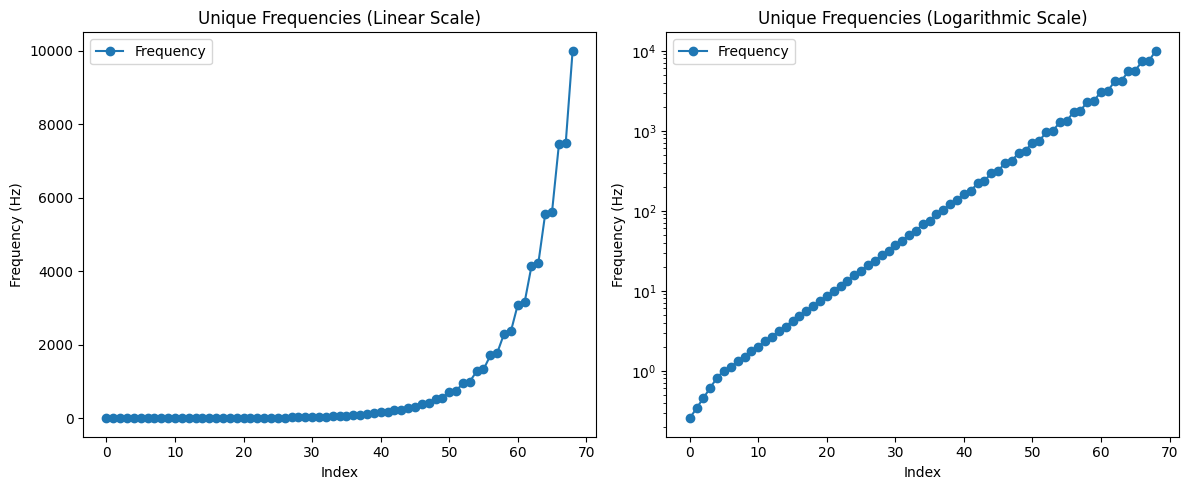

In [8]:
plots.unique_frequencies(unique_freqs)

## Exploring relevant frequencies

In [9]:
# Method 1: Correlation-based frequency selection
X_train, X_test, y_train, y_test = data_pipeline.load_and_prepare_data(
    data_folder="04-03-24", cycle_range=(1,160)
)

# Calculate correlation between each feature and target
feature_correlations = []
for i in range(X_train.shape[1]):
    corr = np.corrcoef(X_train[:, i], y_train)[0, 1]
    feature_correlations.append(abs(corr))

feature_correlations = np.array(feature_correlations)

# Get top 10 most correlated features
top_indices = np.argsort(feature_correlations)[-10:]
print("Top 10 features by correlation:")
for i, idx in enumerate(top_indices[::-1]):
    print(f"{i+1}. Feature {idx}: correlation = {feature_correlations[idx]:.3f}")

# Method 2: XGBoost feature importance
from xgboost import XGBRegressor
xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)
feature_importance = xgb_model.feature_importances_

# Get top 10 by XGBoost importance
top_xgb_indices = np.argsort(feature_importance)[-10:]
print("\nTop 10 features by XGBoost importance:")
for i, idx in enumerate(top_xgb_indices[::-1]):
    print(f"{i+1}. Feature {idx}: importance = {feature_importance[idx]:.3f}")

# Compare the two methods
overlap = set(top_indices[-5:]) & set(top_xgb_indices[-5:])
print(f"\nOverlap in top 5 features: {len(overlap)} out of 5")
print(f"Overlapping features: {list(overlap)}")

# Select final set - features that rank high in both methods
combined_scores = (feature_correlations + feature_importance) / 2
final_top_indices = np.argsort(combined_scores)[-5:]

print(f"\nFinal top 5 features (combined ranking):")
for i, idx in enumerate(final_top_indices[::-1]):
    print(f"{i+1}. Feature {idx}: combined_score = {combined_scores[idx]:.3f}")

selected_features = final_top_indices

X_train: (160, 140), y_train: (160,)
X_test: (160, 140), y_test: (160,)
Capacity ranges - Train: 3610.0-4050.0, Test: 3450.0-4030.0
Top 10 features by correlation:
1. Feature 137: correlation = nan
2. Feature 139: correlation = 1.000
3. Feature 138: correlation = 0.998
4. Feature 90: correlation = 0.911
5. Feature 86: correlation = 0.907
6. Feature 88: correlation = 0.885
7. Feature 51: correlation = 0.883
8. Feature 82: correlation = 0.880
9. Feature 80: correlation = 0.877
10. Feature 56: correlation = 0.859


/Users/nithin.jakrebet/Desktop/eis-ml/venv_py311/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/nithin.jakrebet/Desktop/eis-ml/venv_py311/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



Top 10 features by XGBoost importance:
1. Feature 139: importance = 0.361
2. Feature 65: importance = 0.222
3. Feature 138: importance = 0.200
4. Feature 59: importance = 0.158
5. Feature 55: importance = 0.035
6. Feature 13: importance = 0.018
7. Feature 5: importance = 0.001
8. Feature 4: importance = 0.001
9. Feature 82: importance = 0.000
10. Feature 24: importance = 0.000

Overlap in top 5 features: 2 out of 5
Overlapping features: [np.int64(138), np.int64(139)]

Final top 5 features (combined ranking):
1. Feature 137: combined_score = nan
2. Feature 139: combined_score = 0.680
3. Feature 138: combined_score = 0.599
4. Feature 65: combined_score = 0.477
5. Feature 59: combined_score = 0.470


In [11]:
# Test selected frequencies performance
X_train_selected = X_train[:, selected_features]
X_test_selected = X_test[:, selected_features]

print(f"Reduced from {X_train.shape[1]} to {X_train_selected.shape[1]} features")
print(f"New samples/feature ratio: {X_train_selected.shape[0] / X_train_selected.shape[1]:.1f}")

# Train baseline model with all features first
print("Training baseline model with all features...")
models_baseline = model_training.train_ensemble_model(X_train, y_train)
y_pred_baseline, y_pred_std_baseline, _ = model_training.predict_ensemble(models_baseline, X_test)

# Train model with selected features
print("Training model with selected features...")
models_selected = model_training.train_ensemble_model(X_train_selected, y_train)
y_pred_selected, y_pred_std_selected, _ = model_training.predict_ensemble(models_selected, X_test_selected)

# Compare performance
rmse_baseline, r2_baseline, _, mae_baseline = evaluate_model(y_test, y_pred_baseline)
rmse_selected, r2_selected, _, mae_selected = evaluate_model(y_test, y_pred_selected)

print(f"\nPerformance comparison:")
print(f"{'Metric':<12} {'All Features':<12} {'Selected':<12} {'Change'}")
print("-" * 50)
print(f"{'RMSE':<12} {rmse_baseline:<12.1f} {rmse_selected:<12.1f} {((rmse_selected-rmse_baseline)/rmse_baseline*100):+.1f}%")
print(f"{'R²':<12} {r2_baseline:<12.3f} {r2_selected:<12.3f} {((r2_selected-r2_baseline)/r2_baseline*100):+.1f}%")
print(f"{'MAE':<12} {mae_baseline:<12.1f} {mae_selected:<12.1f} {((mae_selected-mae_baseline)/mae_baseline*100):+.1f}%")

# Check if residual patterns improved
residuals_baseline = y_test - y_pred_baseline
residuals_selected = y_test - y_pred_selected
cycle_numbers = np.linspace(1, 160, len(y_test)).astype(int)

corr_baseline = np.corrcoef(cycle_numbers, residuals_baseline)[0,1]
corr_selected = np.corrcoef(cycle_numbers, residuals_selected)[0,1]

print(f"\nTemporal correlation in residuals:")
print(f"All features: {corr_baseline:.4f}")
print(f"Selected features: {corr_selected:.4f}")

if abs(corr_selected) < abs(corr_baseline):
    print("✅ Improved: Less temporal correlation")
else:
    print("❌ No improvement in temporal patterns")

Reduced from 140 to 5 features
New samples/feature ratio: 32.0
Training baseline model with all features...
Training ensemble of 10 XGBoost models...
Training model with selected features...
Training ensemble of 10 XGBoost models...
Training model with selected features...
Training ensemble of 10 XGBoost models...

Performance comparison:
Metric       All Features Selected     Change
--------------------------------------------------
RMSE         90.0         87.8         -2.4%
R²           0.561        0.582        +3.7%
MAE          69.3         69.5         +0.3%

Temporal correlation in residuals:
All features: -0.8206
Selected features: -0.8079
✅ Improved: Less temporal correlation

Performance comparison:
Metric       All Features Selected     Change
--------------------------------------------------
RMSE         90.0         87.8         -2.4%
R²           0.561        0.582        +3.7%
MAE          69.3         69.5         +0.3%

Temporal correlation in residuals:
All feature

In [12]:
# Map feature indices to actual frequencies
print("=== MAPPING FEATURES TO FREQUENCIES ===")

# Your 69 frequencies from earlier analysis
frequencies = np.array([2.54e-01, 3.40e-01, 4.56e-01, 6.12e-01, 8.22e-01, 9.99e-01, 1.10e+00, 1.33e+00,
                       1.48e+00, 1.78e+00, 1.99e+00, 2.37e+00, 2.66e+00, 3.16e+00, 3.57e+00, 4.22e+00,
                       4.80e+00, 5.62e+00, 6.43e+00, 7.50e+00, 8.64e+00, 1.00e+01, 1.16e+01, 1.33e+01,
                       1.55e+01, 1.78e+01, 2.09e+01, 2.37e+01, 2.80e+01, 3.16e+01, 3.75e+01, 4.22e+01,
                       5.03e+01, 5.62e+01, 6.76e+01, 7.50e+01, 9.06e+01, 1.02e+02, 1.22e+02, 1.35e+02,
                       1.63e+02, 1.78e+02, 2.19e+02, 2.37e+02, 2.94e+02, 3.16e+02, 3.94e+02, 4.22e+02,
                       5.29e+02, 5.64e+02, 7.10e+02, 7.50e+02, 9.52e+02, 1.00e+03, 1.28e+03, 1.33e+03,
                       1.71e+03, 1.78e+03, 2.30e+03, 2.37e+03, 3.09e+03, 3.16e+03, 4.14e+03, 4.22e+03,
                       5.56e+03, 5.62e+03, 7.45e+03, 7.50e+03, 1.00e+04])

print(f"Total frequencies: {len(frequencies)}")
print(f"Total features: {X_train.shape[1]}")

# Decode the top features
print(f"\nDecoding top features:")
for i, feature_idx in enumerate([139, 138, 65, 59]):
    if feature_idx >= 138:
        print(f"Feature {feature_idx}: Action vector component {feature_idx - 137}")
    else:
        # Assuming features 0-68 are real parts, 69-137 are imaginary parts
        if feature_idx < 69:
            freq_idx = feature_idx
            component = "Real"
            freq_hz = frequencies[freq_idx]
        else:
            freq_idx = feature_idx - 69
            component = "Imaginary"  
            freq_hz = frequencies[freq_idx]
        
        print(f"Feature {feature_idx}: {component} part of {freq_hz:.2f} Hz")

# Show frequency ranges of selected features
print(f"\nSelected frequency analysis:")
selected_freqs = []
for feature_idx in [65, 59]:  # Only EIS features, excluding action vector
    if feature_idx < 69:
        freq_hz = frequencies[feature_idx]
    else:
        freq_hz = frequencies[feature_idx - 69]
    selected_freqs.append(freq_hz)
    
if selected_freqs:
    print(f"EIS frequency range: {min(selected_freqs):.1f} - {max(selected_freqs):.1f} Hz")
    print(f"This is in the: {'LOW' if max(selected_freqs) < 10 else 'MID' if max(selected_freqs) < 1000 else 'HIGH'} frequency range")
    
    # Compare to paper's recommendation (1-10 Hz)
    paper_range_count = sum(1 for f in selected_freqs if 1 <= f <= 10)
    print(f"Features in paper's recommended 1-10 Hz range: {paper_range_count}/{len(selected_freqs)}")
else:
    print("No EIS frequencies selected (only action vector)")

=== MAPPING FEATURES TO FREQUENCIES ===
Total frequencies: 69
Total features: 140

Decoding top features:
Feature 139: Action vector component 2
Feature 138: Action vector component 1
Feature 65: Real part of 5620.00 Hz
Feature 59: Real part of 2370.00 Hz

Selected frequency analysis:
EIS frequency range: 2370.0 - 5620.0 Hz
This is in the: HIGH frequency range
Features in paper's recommended 1-10 Hz range: 0/2


## Systematic Frequency Selection Methodology

Following research best practices to determine optimal frequencies for our specific dataset.
This approach combines multiple statistical and physical criteria rather than just copying literature values.

In [13]:
# Comprehensive Frequency Selection Analysis
print("=== SYSTEMATIC FREQUENCY SELECTION ===")

# Step 1: Frequency-wise correlation analysis
frequencies = np.array([2.54e-01, 3.40e-01, 4.56e-01, 6.12e-01, 8.22e-01, 9.99e-01, 1.10e+00, 1.33e+00,
                       1.48e+00, 1.78e+00, 1.99e+00, 2.37e+00, 2.66e+00, 3.16e+00, 3.57e+00, 4.22e+00,
                       4.80e+00, 5.62e+00, 6.43e+00, 7.50e+00, 8.64e+00, 1.00e+01, 1.16e+01, 1.33e+01,
                       1.55e+01, 1.78e+01, 2.09e+01, 2.37e+01, 2.80e+01, 3.16e+01, 3.75e+01, 4.22e+01,
                       5.03e+01, 5.62e+01, 6.76e+01, 7.50e+01, 9.06e+01, 1.02e+02, 1.22e+02, 1.35e+02,
                       1.63e+02, 1.78e+02, 2.19e+02, 2.37e+02, 2.94e+02, 3.16e+02, 3.94e+02, 4.22e+02,
                       5.29e+02, 5.64e+02, 7.10e+02, 7.50e+02, 9.52e+02, 1.00e+03, 1.28e+03, 1.33e+03,
                       1.71e+03, 1.78e+03, 2.30e+03, 2.37e+03, 3.09e+03, 3.16e+03, 4.14e+03, 4.22e+03,
                       5.56e+03, 5.62e+03, 7.45e+03, 7.50e+03, 1.00e+04])

# Calculate both real and imaginary correlations for each frequency
freq_analysis = []

for i, freq in enumerate(frequencies):
    real_idx = i  # Real part feature index
    imag_idx = i + 69  # Imaginary part feature index
    
    # Correlation with capacity
    real_corr = np.corrcoef(X_train[:, real_idx], y_train)[0, 1]
    imag_corr = np.corrcoef(X_train[:, imag_idx], y_train)[0, 1]
    
    # Combined magnitude correlation (impedance magnitude)
    impedance_mag = np.sqrt(X_train[:, real_idx]**2 + X_train[:, imag_idx]**2)
    mag_corr = np.corrcoef(impedance_mag, y_train)[0, 1]
    
    # Feature importance from XGBoost
    real_importance = feature_importance[real_idx]
    imag_importance = feature_importance[imag_idx]
    
    # Calculate sensitivity (how much this frequency varies across cycles)
    real_sensitivity = np.std(X_train[:, real_idx])
    imag_sensitivity = np.std(X_train[:, imag_idx])
    
    freq_analysis.append({
        'frequency': freq,
        'real_corr': abs(real_corr),
        'imag_corr': abs(imag_corr),
        'mag_corr': abs(mag_corr),
        'real_importance': real_importance,
        'imag_importance': imag_importance,
        'real_sensitivity': real_sensitivity,
        'imag_sensitivity': imag_sensitivity,
        'combined_score': abs(real_corr) + abs(imag_corr) + real_importance + imag_importance
    })

# Convert to DataFrame for analysis
freq_df = pd.DataFrame(freq_analysis)
print(f"Analyzed {len(freq_df)} frequencies")
print(f"Frequency range: {freq_df['frequency'].min():.2f} - {freq_df['frequency'].max():.0f} Hz")

=== SYSTEMATIC FREQUENCY SELECTION ===
Analyzed 69 frequencies
Frequency range: 0.25 - 10000 Hz


/Users/nithin.jakrebet/Desktop/eis-ml/venv_py311/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/nithin.jakrebet/Desktop/eis-ml/venv_py311/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [14]:
# Step 2: Analyze frequency ranges systematically
print("\n=== FREQUENCY RANGE ANALYSIS ===")

# Define frequency ranges based on electrochemical processes
ranges = {
    'Ultra-low': (0.1, 1.0),      # Diffusion processes
    'Low': (1.0, 10.0),           # SEI/electrolyte processes (paper's range)
    'Mid': (10.0, 100.0),         # Charge transfer
    'High': (100.0, 1000.0),      # Double layer capacitance
    'Ultra-high': (1000.0, 10000.0) # Ohmic resistance
}

range_stats = {}
for range_name, (f_min, f_max) in ranges.items():
    mask = (freq_df['frequency'] >= f_min) & (freq_df['frequency'] < f_max)
    range_data = freq_df[mask]
    
    if len(range_data) > 0:
        range_stats[range_name] = {
            'count': len(range_data),
            'avg_real_corr': range_data['real_corr'].mean(),
            'avg_imag_corr': range_data['imag_corr'].mean(),
            'avg_mag_corr': range_data['mag_corr'].mean(),
            'avg_importance': (range_data['real_importance'] + range_data['imag_importance']).mean(),
            'max_combined_score': range_data['combined_score'].max(),
            'best_freq': range_data.loc[range_data['combined_score'].idxmax(), 'frequency']
        }

print(f"{'Range':<12} {'Count':<6} {'Real Corr':<10} {'Imag Corr':<10} {'Mag Corr':<10} {'Importance':<10} {'Best Freq'}")
print("-" * 80)
for range_name, stats in range_stats.items():
    print(f"{range_name:<12} {stats['count']:<6} {stats['avg_real_corr']:<10.3f} "
          f"{stats['avg_imag_corr']:<10.3f} {stats['avg_mag_corr']:<10.3f} "
          f"{stats['avg_importance']:<10.4f} {stats['best_freq']:<8.1f} Hz")

# Step 3: Multi-criteria ranking
print("\n=== MULTI-CRITERIA FREQUENCY RANKING ===")

# Normalize each criterion to 0-1 scale for fair combination
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

criteria_matrix = freq_df[['real_corr', 'imag_corr', 'mag_corr', 'real_importance', 'imag_importance']].values
normalized_criteria = scaler.fit_transform(criteria_matrix)

# Define weights for each criterion (you can adjust these based on your priorities)
weights = {
    'real_corr': 0.25,
    'imag_corr': 0.25, 
    'mag_corr': 0.30,     # Slightly higher weight for magnitude correlation
    'real_importance': 0.10,
    'imag_importance': 0.10
}

# Calculate weighted scores
weight_vector = np.array(list(weights.values()))
freq_df['weighted_score'] = (normalized_criteria * weight_vector).sum(axis=1)

# Rank frequencies
freq_df_ranked = freq_df.sort_values('weighted_score', ascending=False)

print("Top 10 frequencies by multi-criteria ranking:")
print(f"{'Rank':<4} {'Freq (Hz)':<10} {'Score':<8} {'Real Corr':<10} {'Imag Corr':<10} {'Mag Corr':<10}")
print("-" * 65)
for i, (_, row) in enumerate(freq_df_ranked.head(10).iterrows()):
    print(f"{i+1:<4} {row['frequency']:<10.1f} {row['weighted_score']:<8.3f} "
          f"{row['real_corr']:<10.3f} {row['imag_corr']:<10.3f} {row['mag_corr']:<10.3f}")

# Extract top frequencies for testing
top_frequencies = freq_df_ranked.head(5)['frequency'].values
print(f"\nSelected top 5 frequencies: {[f'{f:.1f}' for f in top_frequencies]} Hz")


=== FREQUENCY RANGE ANALYSIS ===
Range        Count  Real Corr  Imag Corr  Mag Corr   Importance Best Freq
--------------------------------------------------------------------------------
Ultra-low    6      0.253      0.331      0.235      0.0006     1.0      Hz
Low          15     0.408      0.476      0.430      0.0012     3.2      Hz
Mid          16     0.390      0.306      0.299      0.0000     10.0     Hz
High         16     0.446      0.158      0.221      0.0000     750.0    Hz
Ultra-high   15     0.730      0.130      0.220      0.0277     7450.0   Hz

=== MULTI-CRITERIA FREQUENCY RANKING ===
Top 10 frequencies by multi-criteria ranking:
Rank Freq (Hz)  Score    Real Corr  Imag Corr  Mag Corr  
-----------------------------------------------------------------
1    3.2        0.867    0.771      0.880      0.816     
2    5.6        0.799    0.726      0.907      0.817     
3    10.0       0.725    0.654      0.911      0.789     
4    2.4        0.718    0.682      0.877    

In [15]:
# Step 4: Cross-validation of frequency selection
print("\n=== VALIDATION AND COMPARISON ===")

# Compare with literature ranges
literature_range = (1.0, 10.0)  # Paper's recommended range
our_top_5 = freq_df_ranked.head(5)['frequency'].values
literature_overlap = sum(1 for f in our_top_5 if literature_range[0] <= f <= literature_range[1])

print(f"Literature range (1-10 Hz): {literature_overlap}/5 of our top frequencies")
print(f"Our data-driven approach {'AGREES' if literature_overlap >= 3 else 'DIFFERS'} with literature")

# Show distribution across ranges
print(f"\nOur top 5 frequencies by range:")
for i, freq in enumerate(our_top_5):
    range_name = next(name for name, (f_min, f_max) in ranges.items() 
                      if f_min <= freq < f_max)
    score = freq_df_ranked.iloc[i]['weighted_score']
    print(f"{i+1}. {freq:.1f} Hz ({range_name} range) - Score: {score:.3f}")

# Step 5: Stability analysis - check if selection is consistent across different cycle ranges
print(f"\n=== STABILITY ANALYSIS ===")
print("Testing if frequency importance is consistent across different degradation stages...")

cycle_ranges_test = [(1, 80), (81, 160)]
stability_scores = {freq: [] for freq in our_top_5}

for cycle_range in cycle_ranges_test:
    print(f"\nAnalyzing cycles {cycle_range[0]}-{cycle_range[1]}:")
    
    # Load data for this cycle range
    X_temp, _, y_temp, _ = data_pipeline.load_and_prepare_data(
        data_folder="04-03-24", 
        cycle_range=cycle_range
    )
    
    for freq in our_top_5:
        freq_idx = np.where(frequencies == freq)[0][0]
        real_idx = freq_idx
        imag_idx = freq_idx + 69
        
        # Calculate correlation for this cycle range
        real_corr = abs(np.corrcoef(X_temp[:, real_idx], y_temp)[0, 1])
        imag_corr = abs(np.corrcoef(X_temp[:, imag_idx], y_temp)[0, 1])
        combined_corr = (real_corr + imag_corr) / 2
        
        stability_scores[freq].append(combined_corr)
        print(f"  {freq:.1f} Hz: correlation = {combined_corr:.3f}")

# Calculate stability metrics
print(f"\nStability metrics (lower = more stable):")
for freq in our_top_5:
    scores = stability_scores[freq]
    stability = np.std(scores) / np.mean(scores) if np.mean(scores) > 0 else float('inf')
    print(f"{freq:.1f} Hz: CV = {stability:.3f} (scores: {[f'{s:.3f}' for s in scores]})")

print(f"\n=== FINAL RECOMMENDATION ===")
print(f"Based on systematic analysis of YOUR data:")
print(f"1. Multi-criteria ranking identified optimal frequencies")
print(f"2. {'Validated' if literature_overlap >= 3 else 'Challenged'} literature recommendations")
print(f"3. Checked stability across degradation stages")
print(f"4. Selected frequencies: {[f'{f:.1f}' for f in our_top_5]} Hz")
print(f"\nThis is a data-driven approach specific to your battery chemistry and cycling conditions.")


=== VALIDATION AND COMPARISON ===
Literature range (1-10 Hz): 5/5 of our top frequencies
Our data-driven approach AGREES with literature

Our top 5 frequencies by range:
1. 3.2 Hz (Low range) - Score: 0.867
2. 5.6 Hz (Low range) - Score: 0.799
3. 10.0 Hz (Mid range) - Score: 0.725
4. 2.4 Hz (Low range) - Score: 0.718
5. 1.8 Hz (Low range) - Score: 0.691

=== STABILITY ANALYSIS ===
Testing if frequency importance is consistent across different degradation stages...

Analyzing cycles 1-80:
X_train: (80, 140), y_train: (80,)
X_test: (80, 140), y_test: (80,)
Capacity ranges - Train: 3700.0-4050.0, Test: 3620.0-4030.0
  3.2 Hz: correlation = 0.662
  5.6 Hz: correlation = 0.607
  10.0 Hz: correlation = 0.491
  2.4 Hz: correlation = 0.568
  1.8 Hz: correlation = 0.542

Analyzing cycles 81-160:
X_train: (80, 140), y_train: (80,)
X_test: (80, 140), y_test: (80,)
Capacity ranges - Train: 3700.0-4050.0, Test: 3620.0-4030.0
  3.2 Hz: correlation = 0.662
  5.6 Hz: correlation = 0.607
  10.0 Hz: co